## Differential Evolution

In this session, we will discover how Differential Evolution (DE) works. We will explore the underlying principles, implement core components from scratch, apply DE to classic benchmark functions, visualize its dynamics through a generated GIF, and tackle constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import PathCollection
from typing import Callable
from dataclasses import dataclass

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam, Momentum, and CMA-ES.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

BOUNDS = [(-5, 5), (-5, 5)]

### Differential Evolution

Differential Evolution is a simple yet powerful **population-based search algorithm** for continuous optimization. At every iteration it maintains a population of $pop\_size$ candidate solutions, each an $n$-dimensional real-valued vector. Three straightforward operators: mutation, crossover, and selection, are applied to push the population toward regions of lower objective value.

#### 1. Initialisation  
Randomly sample $pop\_size$ vectors inside the problem's bounds.

#### 2. Mutation  
For each target vector $x_i$:

1. Select three distinct solutions $a$, $b$, $c$ (none equal to $x_i$) from current population.  
2. Create the mutant  
   $$v = a + F\,(b - c)$$
   where $F \in (0.4,1^+)$ is the scaling factor. The difference $(b-c)$ supplies direction and scale; $F$ stretches or shrinks the step.

#### 3. Crossover  
Blend the mutant $v$ with its target $x_i$ to form the trial vector \(u\):

- For each coordinate $j$, copy $v_j$ into $u_j$ with probability $CR$; otherwise copy $x_{i,j}$.  
- Force at least one coordinate to come from $v$ so that $u \neq x_i$.

Here $CR \in [0,1]$ is the *crossover rate*: higher $CR$ means aggressive mixing; lower $CR$ leaves the mutant mostly intact.

#### 4. Selection  
Evaluate the objective $f(\cdot)$: $u \text{ replaces } x_i \quad \text{if} \quad f(u) < f(x_i)$

Greedy replacement ensures the population does not deteriorate.

#### 5. Iteration & Termination  
After every target has produced a trial and selection is done, the new population is complete. Repeat until a generation limit, a fitness threshold, or a stall criterion is reached.

#### 6. Parameter intuition  

| Parameter | Typical range |
|-----------|---------------|
| Differential weight \(F\) | 0.4 – 1.0 |
| Crossover rate \(CR\)     | 0.1 – 0.9 |
| Population size \(P\)     | $5n$ – $10n$ |

In [3]:
@dataclass
class DEResult:
    best_vector: np.ndarray
    best_value: float
    history: list[np.ndarray]


def differential_evolution(
    func: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]] = BOUNDS,
    pop_size: int = 50,
    F: float = 0.8,
    CR: float = 0.9,
    max_gen: int = 100,
    seed: int | None = None,
) -> DEResult:

    rng = np.random.default_rng(seed)

    dimensions = len(bounds)
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])

    # Exercise 1 - Initialization
    population = rng.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(pop_size, dimensions)
    )

    fitness = np.array([func(individual) for individual in population])

    history = [population.copy()]

    for generation in range(max_gen):
        new_population = population.copy()
        new_fitness = fitness.copy()

        for i in range(pop_size):
            target_vector = population[i]

            # Exercise 2 - Mutation
            possible_indices = [idx for idx in range(pop_size) if idx != i]
            a_idx, b_idx, c_idx = rng.choice(possible_indices, size=3, replace=False)

            a = population[a_idx]
            b = population[b_idx]
            c = population[c_idx]

            mutant_vector = a + F * (b - c)
            mutant_vector = np.clip(mutant_vector, lower_bounds, upper_bounds)

            # Exercise 3 - Crossover
            trial_vector = target_vector.copy()
            j_rand = rng.integers(0, dimensions)

            for j in range(dimensions):
                if rng.random() < CR or j == j_rand:
                    trial_vector[j] = mutant_vector[j]

            # Exercise 4 - Selection
            trial_fitness = func(trial_vector)

            if trial_fitness <= fitness[i]:
                new_population[i] = trial_vector
                new_fitness[i] = trial_fitness

        population = new_population
        fitness = new_fitness

        history.append(population.copy())

    best_idx = np.argmin(fitness)

    return DEResult(
        best_vector=population[best_idx].copy(),
        best_value=float(fitness[best_idx]),
        history=history
    )

### Test implemented DE

In [4]:
result = differential_evolution(sphere, bounds=BOUNDS, pop_size=50)

print("Best vector:", result.best_vector)
print("Best value:", result.best_value)

Best vector: [ 1.38501266e-09 -1.72428920e-08]
Best value: 2.99235583627291e-16


### Visualizing Search Dynamics

In [5]:
def animate_de(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
    bounds: list[tuple[float, float]] = BOUNDS,
    frames: int | None = None,
    filename: str = "de_animation.gif",
) -> None:
    """
    Creates and saves a GIF showing how the DE population moves over generations.
    """
    if frames is None:
        frames = len(history)

    assert len(bounds) == 2, "This function only supports 2D visualization (expected 2 bounds)."
    x_bounds = (bounds[0][0], bounds[0][1])
    y_bounds = (bounds[1][0], bounds[1][1])

    x = np.linspace(x_bounds[0], x_bounds[1], 200)
    y = np.linspace(y_bounds[0], y_bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
    fig.colorbar(contour, ax=ax)

    # Track only the scatters we add so we can remove them between frames
    # without touching the contour (works across matplotlib versions).
    scatters: list = []

    def update(i: int):
        while scatters:
            scatters.pop().remove()

        ax.set_title(f"Generation {i}")

        DECAY_CONSTANT = 10

        # Plot all generations up to i, with alpha decreasing for older points
        for j in range(i + 1):
            age = i - j
            alpha = float(np.exp(-age / DECAY_CONSTANT))
            pop_j = history[j]
            scatters.append(
                ax.scatter(pop_j[:, 0], pop_j[:, 1], s=24, color="red", edgecolors="none", alpha=alpha)
            )

        # Return an empty tuple since we're redrawing everything
        return ()

    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=200,
        blit=False,  # must be False since we redraw each frame
    )

    writer = animation.PillowWriter(fps=5)
    anim.save(filename, writer=writer)
    plt.close(fig)
    print(f"Animation saved to {filename}")

In [6]:
animate_de(func=sphere, history=result.history)

Animation saved to de_animation.gif


### Experiments
Run DE on all three problems: Sphere, Rosenbrock and Rastrigin. For each problem:
- Generate and analyze convergence plots showing the progression of the best fitness value over iterations.
- Visualize the population dynamics over time to illustrate how the search space is explored and exploited.

In [7]:
problems = {
    "Sphere": sphere,
    "Rosenbrock": rosenbrock,
    "Rastrigin": rastrigin
}

results = {}

for name, func in problems.items():
    results[name] = differential_evolution(
        func=func,
        bounds=BOUNDS,
        pop_size=50,
        F=0.8,
        CR=0.9,
        max_gen=100,
        seed=42
    )

    print(name)
    print("Best vector:", results[name].best_vector)
    print("Best value:", results[name].best_value)
    print()

Sphere
Best vector: [3.14811727e-09 3.47906601e-09]
Best value: 2.2014542651365103e-17

Rosenbrock
Best vector: [1.00000059 1.00000123]
Best value: 5.471108754849851e-13

Rastrigin
Best vector: [-8.05750553e-07  8.28301975e-07]
Best value: 2.6491520088711695e-10



## Komentarz
Dla funkcji Sphere najlepszy wektor jest praktycznie równy [0, 0], a wartość funkcji jest bliska zera.
To oznacza, że algorytm poprawnie znalazł minimum globalne.
Dla Rosenbrocka najlepszy wektor jest bardzo blisko [1, 1], czyli prawdziwego minimum tej funkcji.
Dla Rastrigina najlepszy wektor jest bardzo blisko [0, 0], a wartość funkcji prawie zerowa.

DE poradził sobie nawet z funkcją mającą wiele lokalnych minimów.

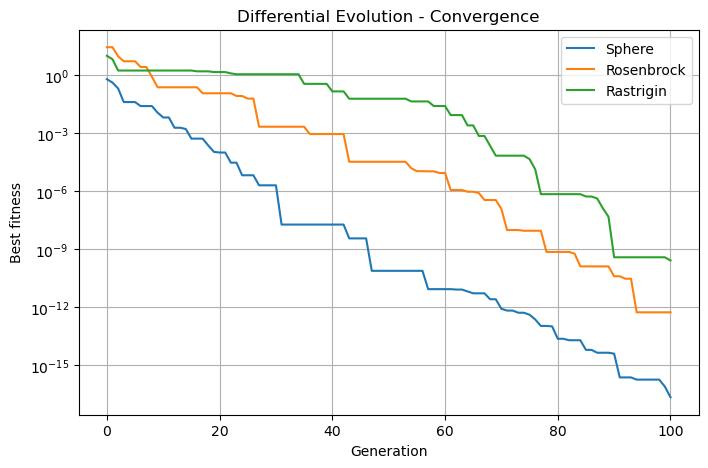

In [8]:
plt.figure(figsize=(8, 5))

for name, result in results.items():
    func = problems[name]

    best_values = [
        min(func(ind) for ind in population)
        for population in result.history
    ]

    plt.plot(best_values, label=name)

plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Differential Evolution - Convergence")
plt.legend()
plt.grid(True)
plt.show()

## Komentarz
Na wykresie widać, że najlepsza wartość funkcji maleje w kolejnych generacjach. Sphere zbiega najszybciej, bo jest najprostsza i ma jedno minimum. Rosenbrock zbiega wolniej, ponieważ ma wąską dolinę minimum. Rastrigin jest trudniejszy przez wiele minimów lokalnych, ale DE również znalazł bardzo dobry wynik.

In [9]:
animate_de(func=sphere, history=results["Sphere"].history, filename="de_sphere.gif")
animate_de(func=rosenbrock, history=results["Rosenbrock"].history, filename="de_rosenbrock.gif")
animate_de(func=rastrigin, history=results["Rastrigin"].history, filename="de_rastrigin.gif")

Animation saved to de_sphere.gif
Animation saved to de_rosenbrock.gif
Animation saved to de_rastrigin.gif


## Komentarz
Animacje pokazują, jak populacja początkowo jest rozproszona po całej przestrzeni, a później stopniowo skupia się w okolicy minimum.

### Hyperparameters in Differential Evolution

Two hyperparameters drive DE's exploration/exploitation tradeoff:

- **Scaling factor $F$** controls the magnitude of the differential mutation step. Large $F$ → big jumps (exploration); small $F$ → small refinements (exploitation).
- **Crossover rate $CR$** controls how much of the mutant ends up in the trial vector. Large $CR$ → aggressive mixing across coordinates; small $CR$ → trial mostly inherits the target.

#### Task: $F \times CR$ grid search on Rastrigin

Rastrigin is highly multimodal, so it is a good stress test for these knobs. Run a grid over

- $F \in \{0.3,\ 0.5,\ 0.7,\ 0.9\}$
- $CR \in \{0.1,\ 0.3,\ 0.5,\ 0.7,\ 0.9\}$

For each $(F, CR)$ pair, run DE **5 times** with different seeds on **10D Rastrigin** (`bounds = [(-5, 5)] * 10`, `pop_size = 50`, `max_gen = 200`) and record the best final fitness. Aggregate by mean across seeds.

**Deliverables**

1. A heatmap of mean best fitness over the $F \times CR$ grid (e.g. `plt.imshow` with annotated cells, or `seaborn.heatmap`).
2. A short written analysis (3–5 sentences):
   - Which region of the grid performs best, and why?
   - What happens at the extreme corners (low $F$ + low $CR$; high $F$ + high $CR$)?
   - How does the answer connect to the exploration/exploitation framing above?

In [10]:
F_values = [0.3, 0.5, 0.7, 0.9]
CR_values = [0.1, 0.3, 0.5, 0.7, 0.9]
seeds = [0, 1, 2, 3, 4]

bounds_10d = [(-5, 5)] * 10

mean_best_fitness = np.zeros((len(F_values), len(CR_values)))

for i, F in enumerate(F_values):
    for j, CR in enumerate(CR_values):
        final_values = []

        for seed in seeds:
            result = differential_evolution(
                func=rastrigin,
                bounds=bounds_10d,
                pop_size=50,
                F=F,
                CR=CR,
                max_gen=200,
                seed=seed
            )

            final_values.append(result.best_value)

        mean_best_fitness[i, j] = np.mean(final_values)

        print(
            f"F={F}, CR={CR}, "
            f"mean best fitness={mean_best_fitness[i, j]:.4f}"
        )

F=0.3, CR=0.1, mean best fitness=0.0702
F=0.3, CR=0.3, mean best fitness=6.6239
F=0.3, CR=0.5, mean best fitness=12.1131
F=0.3, CR=0.7, mean best fitness=17.9781
F=0.3, CR=0.9, mean best fitness=17.5019
F=0.5, CR=0.1, mean best fitness=0.3637
F=0.5, CR=0.3, mean best fitness=7.8270
F=0.5, CR=0.5, mean best fitness=17.3180
F=0.5, CR=0.7, mean best fitness=23.3366
F=0.5, CR=0.9, mean best fitness=31.8244
F=0.7, CR=0.1, mean best fitness=3.5617
F=0.7, CR=0.3, mean best fitness=16.4782
F=0.7, CR=0.5, mean best fitness=26.3905
F=0.7, CR=0.7, mean best fitness=34.6251
F=0.7, CR=0.9, mean best fitness=47.8581
F=0.9, CR=0.1, mean best fitness=1.0361
F=0.9, CR=0.3, mean best fitness=8.6914
F=0.9, CR=0.5, mean best fitness=22.8259
F=0.9, CR=0.7, mean best fitness=36.1582
F=0.9, CR=0.9, mean best fitness=59.0778


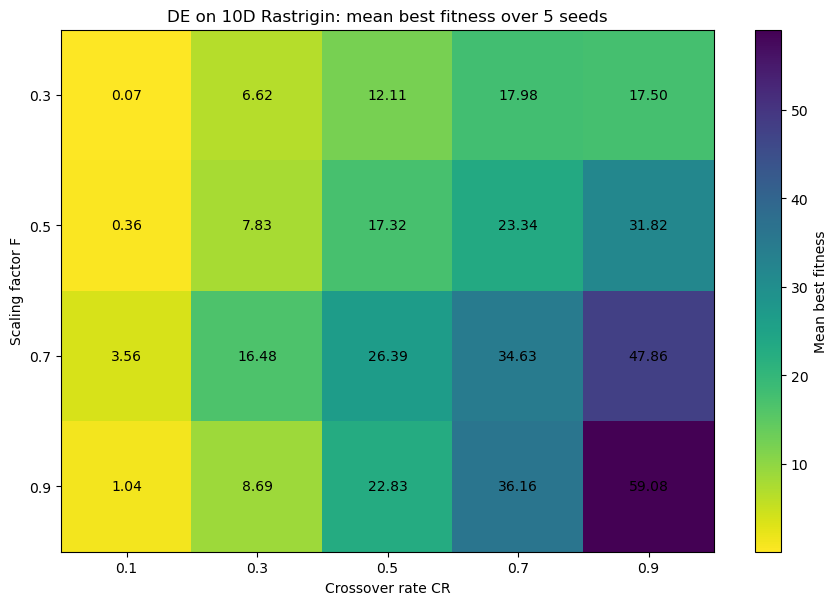

In [11]:
plt.figure(figsize=(9, 6))

im = plt.imshow(mean_best_fitness, cmap="viridis_r")

plt.colorbar(im, label="Mean best fitness")
plt.xticks(range(len(CR_values)), CR_values)
plt.yticks(range(len(F_values)), F_values)

plt.xlabel("Crossover rate CR")
plt.ylabel("Scaling factor F")
plt.title("DE on 10D Rastrigin: mean best fitness over 5 seeds")

for i in range(len(F_values)):
    for j in range(len(CR_values)):
        plt.text(
            j,
            i,
            f"{mean_best_fitness[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()

In [12]:
best_idx = np.unravel_index(np.argmin(mean_best_fitness), mean_best_fitness.shape)

best_F = F_values[best_idx[0]]
best_CR = CR_values[best_idx[1]]
best_value = mean_best_fitness[best_idx]

print(f"Best region: F={best_F}, CR={best_CR}")
print(f"Best mean fitness: {best_value:.6f}")

Best region: F=0.3, CR=0.1
Best mean fitness: 0.070211


## Komentarz
Najlepszy wynik uzyskano dla F = 0.3, CR = 0.1, gdzie średni best fitness wyniósł około 0.07, czyli bardzo blisko minimum globalnego. Oznacza to, że dla 10D Rastrigina najlepiej zadziałały małe kroki i niewielkie mieszanie współrzędnych. Przy niskim F i niskim CR algorytm lepiej dopracowywał rozwiązania, zamiast skakać po przestrzeni.

W skrajnym przypadku wysokie F i CR, np. F = 0.9, CR = 0.9, wynik był najgorszy (59.0`), bo mutacje były zbyt duże i chaotyczne. Widać więc, że zbyt mocna eksploracja utrudniała stabilną zbieżność, a w tym eksperymencie korzystniejsza była większa eksploatacja znalezionych obszarów.


### SHADE: Success-History Based Adaptive Differential Evolution

SHADE is an advanced variant of DE designed to enhance optimization performance through adaptive parameter control. Your task is to critically analyze the research paper [Success-History Based Parameter Adaptation for Differential Evolution](https://metahack.org/CEC2013-SHADE.pdf).
- Summarize the key concepts and mechanisms introduced in SHADE.
- Explain how SHADE differs from the standard DE algorithm.
- Discuss the motivation behind these changes and the empirical improvements demonstrated in the study.

## Odpowiedź

1. Najważniejsze pomysły w SHADE

SHADE to ulepszona wersja Differential Evolution. Główna idea polega na tym, że algorytm sam dobiera parametry F i CR w trakcie działania. Zapamiętuje wartości tych parametrów, które wcześniej dały dobre wyniki, i częściej korzysta z podobnych wartości w kolejnych iteracjach.

2. Różnice względem zwykłego DE

W standardowym DE parametry F i CR są ustawione ręcznie i zwykle nie zmieniają się podczas działania algorytmu. W SHADE te parametry są adaptowane automatycznie na podstawie historii sukcesów. Dzięki temu algorytm może lepiej dopasować się do problemu bez ciągłego ręcznego strojenia.

3. Po co wprowadzono te zmiany?

Zmiany wprowadzono, ponieważ źle dobrane F i CR mogą bardzo pogorszyć wyniki DE. SHADE próbuje sam znaleźć dobre ustawienia, co poprawia równowagę między eksploracją a eksploatacją. W badaniach pokazano, że SHADE często osiągał lepsze i stabilniejsze wyniki niż klasyczny DE oraz inne jego warianty.

### Recommended Reading
1. https://pablormier.github.io/2017/09/05/a-tutorial-on-differential-evolution-with-python/
2. Das, Swagatam, and Ponnuthurai Nagaratnam Suganthan. [Differential evolution: A survey of the state-of-the-art.](https://i2pc.es/coss/Docencia/SignalProcessingReviews/Das2011.pdf)
3. Tanabe, Ryoji, and Alex Fukunaga. [Success-history based parameter adaptation for differential evolution.](https://metahack.org/CEC2013-SHADE.pdf)